# Riskfolio-Lib Tutorial: 
<br><a href="https://www.kqzyfj.com/click-101360347-15150084?url=https%3A%2F%2Flink.springer.com%2Fbook%2F9783031843037" target="_blank">
<div>
<img src="https://raw.githubusercontent.com/dcajasn/Riskfolio-Lib/refs/heads/master/docs/source/_static/Button.png" height="40" />
</div>
<br>
</a>
<a href="https://www.paypal.com/ncp/payment/GN55W4UQ7VAMN" target="_blank">
<div>
<img src="https://raw.githubusercontent.com/dcajasn/Riskfolio-Lib/refs/heads/master/docs/source/_static/Button2.png" height="40" />
</div>
</a>

<br><a href='https://ko-fi.com/B0B833SXD' target='_blank'><img height='36' style='border:0px;height:36px;' src='https://cdn.ko-fi.com/cdn/kofi1.png?v=2' border='0' alt='Buy Me a Coffee at ko-fi.com' /></a> 
<br>
<br>__[Financionerioncios](https://financioneroncios.wordpress.com)__
<br>__[Orenji](https://www.linkedin.com/company/orenj-i)__
<br>__[Riskfolio-Lib](https://portfoliooptimization.org)__
<br>__[Dany Cajas](https://www.linkedin.com/in/dany-cajas/)__

## Tutorial 21: Logarithmic Mean Risk Optimization (Kelly Criterion)

## 1. Downloading the data:

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import warnings

warnings.filterwarnings("ignore")
pd.options.display.float_format = '{:.4%}'.format

# Date range
start = '2000-01-01'
end = '2019-12-31'

# Tickers of assets
assets = ['AIG', 'AKAM', 'AMT', 'APA', 'BA', 'BAX', 'BKNG',
          'BMY', 'CMCSA', 'CNP', 'CPB', 'DE', 'MO', 'MSFT', 'NI',
          'NKTR', 'NTAP', 'PCAR', 'PSA', 'REGN', 'SBAC', 'SHW', 'T',
          'TGT', 'TMO', 'TTWO']

assets.sort()

# Downloading data
data = yf.download(assets, start = start, end = end, auto_adjust=False)
data = data.loc[:,('Adj Close', slice(None))]
data.columns = assets

[*********************100%***********************]  26 of 26 completed


In [2]:
# Calculating returns

#Y = data[assets].pct_change().dropna()
Y = data[assets].copy()
Y = Y.resample('M').last().pct_change().dropna()
print(Y.shape)
display(Y.head())

(239, 26)


,AIG,AKAM,AMT,APA,BA,BAX,BKNG,BMY,CMCSA,CNP,...,NTAP,PCAR,PSA,REGN,SBAC,SHW,T,TGT,TMO,TTWO
Date,,,,,,,,,,,,,,,,,,,,,
2000-02-29,-15.2695%,4.8670%,37.2822%,0.0000%,-16.7100%,-14.6771%,-3.5560%,-13.5849%,-7.2464%,-8.3352%,...,88.0449%,4.6443%,-2.7549%,358.8832%,33.6083%,9.2481%,-11.9534%,-10.2962%,-9.7473%,0.0000%
2000-03-31,23.8863%,-38.4450%,0.2538%,36.5170%,2.3689%,15.0229%,43.0168%,-0.2184%,3.1250%,14.5896%,...,-12.3179%,16.1104%,-3.8081%,-47.6770%,8.6419%,15.6862%,11.5894%,26.6950%,30.3999%,6.5327%
2000-04-30,0.1712%,-38.5154%,-5.6962%,-2.6381%,4.9587%,8.5878%,-20.9375%,-7.8650%,-5.4545%,12.9974%,...,-10.6496%,-4.8751%,6.5476%,-3.3827%,-7.6704%,12.4294%,4.7667%,-10.9532%,-4.9079%,-27.3585%
2000-05-31,2.6662%,-32.4905%,-20.2684%,25.6129%,-1.2139%,2.1114%,-39.7233%,5.0060%,-3.6859%,8.7704%,...,-12.6796%,-11.3612%,-0.2793%,-28.6652%,-8.3077%,-6.0495%,-0.2853%,-5.6896%,-4.1936%,-5.8442%
2000-06-30,4.3864%,77.8792%,12.2895%,-3.3385%,7.0400%,5.7330%,-0.3689%,5.7889%,3.4942%,3.5011%,...,24.6854%,-5.2239%,6.1300%,46.3190%,39.4296%,-8.8709%,0.7153%,-7.4776%,13.4680%,33.7931%


## 2. Estimating Logarithmic Mean Variance Portfolios

### 2.1 Calculating the portfolio that maximizes Risk Adjusted Return.

In [3]:
import riskfolio as rp

# Building the portfolio object
port = rp.Portfolio(returns=Y)

# Calculating optimal portfolio

# Select method and estimate input parameters:

method_mu='hist' # Method to estimate expected returns based on historical data.
method_cov='hist' # Method to estimate covariance matrix based on historical data.

port.assets_stats(method_mu=method_mu, method_cov=method_cov)

# Estimate optimal portfolio:

port.solvers = ['MOSEK']
model='Classic' # Could be Classic (historical), BL (Black Litterman) or FM (Factor Model)
rm = 'MV' # Risk measure used, this time will be variance
obj = 'Sharpe' # Objective function, could be MinRisk, MaxRet, Utility or Sharpe
hist = True # Use historical scenarios for risk measures that depend on scenarios
rf = 0 # Risk free rate
l = 0 # Risk aversion factor, only useful when obj is 'Utility'

w_1 = port.optimization(model=model, rm=rm, obj=obj, kelly=None, rf=rf, l=l, hist=hist)
w_2 = port.optimization(model=model, rm=rm, obj=obj, kelly='approx', rf=rf, l=l, hist=hist)
w_3 = port.optimization(model=model, rm=rm, obj=obj, kelly='exact', rf=rf, l=l, hist=hist)

w = pd.concat([w_1, w_2, w_3], axis=1)
w.columns = ['Arithmetic', 'Log Approx', 'Log Exact']

display(w.style.format("{:.2%}").background_gradient(cmap='YlGn'))

,Arithmetic,Log Approx,Log Exact
AIG,0.00%,0.00%,0.00%
AKAM,0.00%,0.00%,0.00%
AMT,0.00%,0.00%,0.00%
APA,0.00%,0.00%,0.00%
BA,2.12%,2.10%,2.08%
BAX,0.89%,1.46%,1.52%
BKNG,2.45%,2.34%,2.33%
BMY,0.00%,0.00%,0.00%
CMCSA,0.00%,0.00%,0.00%
CNP,0.29%,0.75%,0.81%


<Axes: >

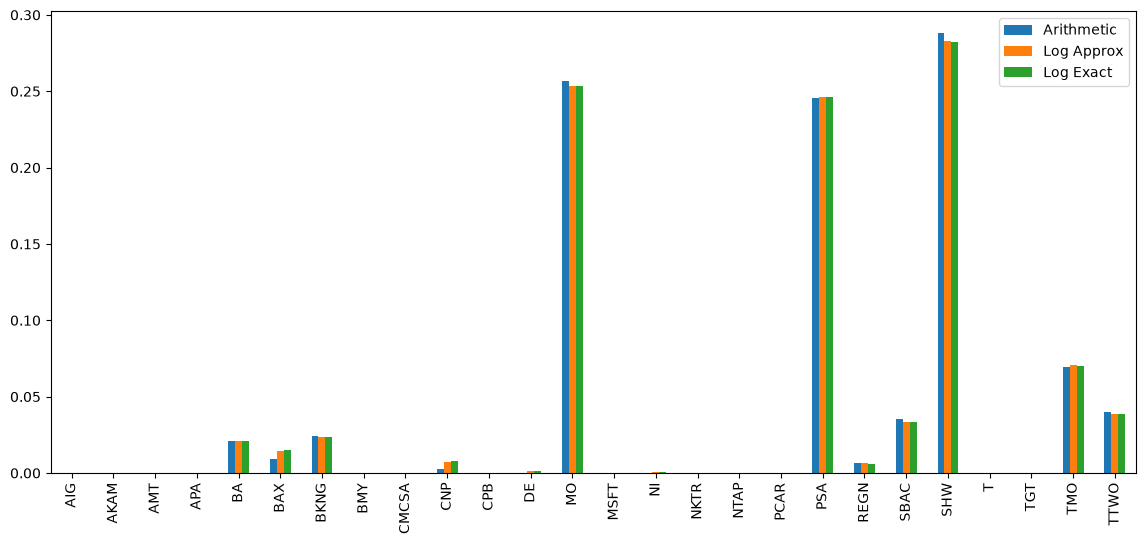

In [4]:
fig, ax = plt.subplots(figsize=(14,6))
w.plot(kind='bar', ax = ax)

In [5]:
returns = port.returns
cov = port.cov

y = 1/(returns.shape[0]) * np.sum(np.log(1 + returns @ w_1.to_numpy()))
x = rp.Sharpe_Risk(returns=returns, w=w_1, cov=cov, rm=rm, rf=rf, alpha=0.05)
print("Risk Adjusted Return:")
print("Arithmetic", (y/x).item() * 12**0.5)

y = 1/(returns.shape[0]) * np.sum(np.log(1 + returns @ w_2.to_numpy()))
x = rp.Sharpe_Risk(returns=returns, w=w_2, cov=cov, rm=rm, rf=rf, alpha=0.05)
print("Log Approx", (y/x).item() * 12**0.5)

y = 1/(returns.shape[0]) * np.sum(np.log(1 + returns @ w_3.to_numpy()))
x = rp.Sharpe_Risk(returns=returns, w=w_3, cov=cov, rm=rm, rf=rf, alpha=0.05)
print("Log Exact", (y/x).item() * 12**0.5)

Risk Adjusted Return:
Arithmetic 1.3879927130966454
Log Approx 1.3883077869459965
Log Exact 1.3883113073887707


### 2.2 Calculate efficient frontier

In [6]:
points = 40 # Number of points of the frontier

frontier = port.efficient_frontier(model=model, rm=rm, kelly="exact", points=points, rf=rf, hist=hist)

display(frontier.T.head())

,AIG,AKAM,AMT,APA,BA,BAX,BKNG,BMY,CMCSA,CNP,...,NTAP,PCAR,PSA,REGN,SBAC,SHW,T,TGT,TMO,TTWO
0,0.0000%,0.0000%,0.0000%,0.5520%,0.0000%,6.4650%,0.0000%,7.8723%,1.9797%,5.2055%,...,0.0000%,0.0000%,20.2448%,0.3548%,0.0000%,11.9160%,6.5744%,0.9258%,0.6094%,1.4545%
1,0.0000%,0.0000%,0.0000%,0.0000%,1.4395%,4.2540%,1.2858%,2.4171%,0.0000%,3.3189%,...,0.0000%,0.0000%,23.5882%,0.4781%,1.5903%,22.4025%,1.8834%,0.0000%,5.4603%,2.7258%
2,0.0000%,0.0000%,0.0000%,0.0000%,2.0268%,2.8878%,2.0442%,0.0000%,0.0000%,1.8377%,...,0.0000%,0.0001%,24.7251%,0.5067%,2.7860%,26.8253%,0.0000%,0.0000%,7.1135%,3.3734%
3,0.0000%,0.0000%,0.0000%,0.0000%,0.9111%,0.0000%,2.9761%,0.0000%,0.0000%,0.0000%,...,0.0000%,0.0000%,22.6437%,1.2854%,4.5504%,30.9201%,0.0000%,0.0000%,5.0634%,4.9931%
4,0.0000%,0.0000%,0.0000%,0.0000%,0.0000%,0.0000%,3.8338%,0.0000%,0.0000%,0.0000%,...,0.0000%,0.0000%,18.9758%,2.3206%,5.9706%,33.7376%,0.0000%,0.0000%,1.2514%,6.4694%


<Axes: >

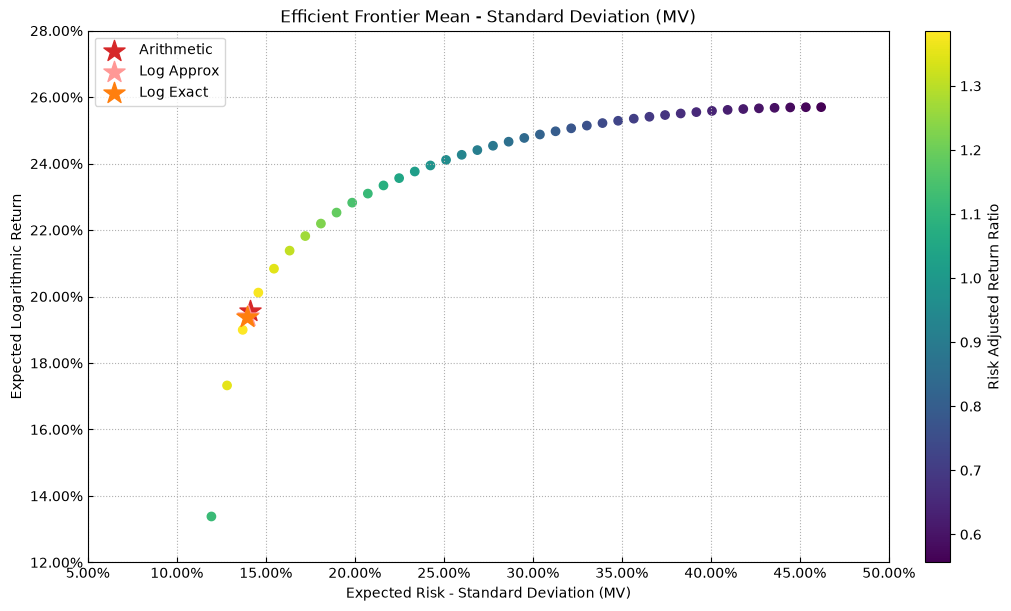

In [7]:
# Plotting the efficient frontier

label = 'Max Risk Adjusted Log Return Portfolio' # Title of point
mu = port.mu # Expected returns
cov = port.cov # Covariance matrix
returns = port.returns # Returns of the assets

fig, ax = plt.subplots(figsize=(10,6))
rp.plot_frontier(w_frontier=frontier,
                 mu=mu,
                 cov=cov,
                 returns=returns,
                 rm=rm,
                 kelly=True,
                 rf=rf,
                 alpha=0.05,
                 cmap='viridis',
                 w=w,
                 label=label,
                 marker='*',
                 s=16,
                 c='r',
                 height=6,
                 width=10,
                 t_factor=12,
                 ax=ax)

## 2. Estimating Logarithmic Mean EVaR Portfolios

### 2.1 Calculating the portfolio that maximizes Risk Adjusted Return.

In [8]:
rm = 'EVaR' # Risk measure

w_1 = port.optimization(model=model, rm=rm, obj=obj, kelly=None, rf=rf, l=l, hist=hist)
w_2 = port.optimization(model=model, rm=rm, obj=obj, kelly='approx', rf=rf, l=l, hist=hist)
w_3 = port.optimization(model=model, rm=rm, obj=obj, kelly='exact', rf=rf, l=l, hist=hist)

w = pd.concat([w_1, w_2, w_3], axis=1)
w.columns = ['Arithmetic', 'Log Approx', 'Log Exact']

display(w.style.format("{:.2%}").background_gradient(cmap='YlGn'))

,Arithmetic,Log Approx,Log Exact
AIG,0.00%,0.00%,0.00%
AKAM,0.00%,0.00%,0.00%
AMT,0.00%,0.00%,0.00%
APA,2.47%,2.14%,2.20%
BA,0.00%,0.00%,0.00%
BAX,9.75%,9.86%,9.85%
BKNG,0.00%,0.00%,0.00%
BMY,0.00%,0.00%,0.00%
CMCSA,0.00%,0.00%,0.00%
CNP,0.00%,0.00%,0.00%


<Axes: >

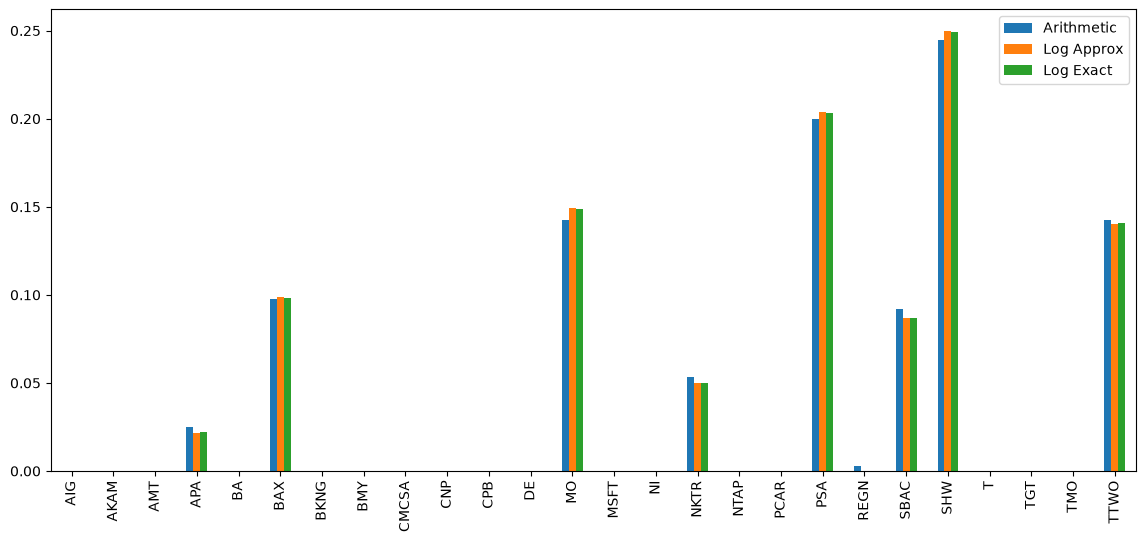

In [9]:
fig, ax = plt.subplots(figsize=(14,6))
w.plot(kind='bar', ax = ax)

In [10]:
returns = port.returns
cov = port.cov

y = 1/(returns.shape[0]) * np.sum(np.log(1 + returns @ w_1.to_numpy()))
x = rp.Sharpe_Risk(returns=returns, w=w_1, cov=cov, rm=rm, rf=rf, alpha=0.05)
print("Risk Adjusted Return:")
print("Arithmetic", (y/x).item() * 12**0.5)

y = 1/(returns.shape[0]) * np.sum(np.log(1 + returns @ w_2.to_numpy()))
x = rp.Sharpe_Risk(returns=returns, w=w_2, cov=cov, rm=rm, rf=rf, alpha=0.05)
print("Log Approx", (y/x).item() * 12**0.5)

y = 1/(returns.shape[0]) * np.sum(np.log(1 + returns @ w_3.to_numpy()))
x = rp.Sharpe_Risk(returns=returns, w=w_3, cov=cov, rm=rm, rf=rf, alpha=0.05)
print("Log Exact", (y/x).item() * 12**0.5)

Risk Adjusted Return:
Arithmetic 0.7147314618630409
Log Approx 0.7154782744755314
Log Exact 0.7154817224935212


### 3.2 Calculate efficient frontier

In [11]:
points = 40 # Number of points of the frontier

frontier = port.efficient_frontier(model=model, rm=rm, kelly="exact", points=points, rf=rf, hist=hist)

display(frontier.T.head())

,AIG,AKAM,AMT,APA,BA,BAX,BKNG,BMY,CMCSA,CNP,...,NTAP,PCAR,PSA,REGN,SBAC,SHW,T,TGT,TMO,TTWO
0,0.0000%,1.7789%,0.0000%,0.0000%,0.0000%,3.7501%,1.1663%,17.9872%,0.0000%,3.0106%,...,0.0000%,0.0000%,14.7339%,0.0000%,5.5735%,10.2384%,0.4441%,0.0000%,5.6695%,6.5265%
1,0.0000%,0.0000%,0.0000%,0.2654%,0.0000%,12.2252%,0.0000%,0.0000%,0.0000%,1.4294%,...,0.0000%,0.0000%,18.0629%,0.0000%,6.6917%,24.9498%,0.0000%,0.0000%,0.0000%,13.4902%
2,0.0000%,0.0000%,0.0000%,2.4483%,0.0000%,10.7138%,0.0000%,0.0000%,0.0000%,0.0000%,...,0.0000%,0.0000%,19.9613%,0.0000%,8.1686%,24.7732%,0.0000%,0.0000%,0.0000%,13.9067%
3,0.0000%,0.0000%,0.0000%,1.6961%,0.0000%,8.5022%,0.0000%,0.0000%,0.0000%,0.0000%,...,0.0000%,0.0000%,20.1495%,1.5460%,9.2121%,25.2752%,0.0000%,0.0000%,0.0000%,13.7102%
4,0.0000%,0.0000%,0.0000%,0.7792%,0.0000%,6.6239%,0.0000%,0.0000%,0.0000%,0.0000%,...,0.0000%,0.0000%,20.1074%,3.3095%,9.8244%,25.5663%,0.0000%,0.0000%,0.0000%,13.4745%


<Axes: >

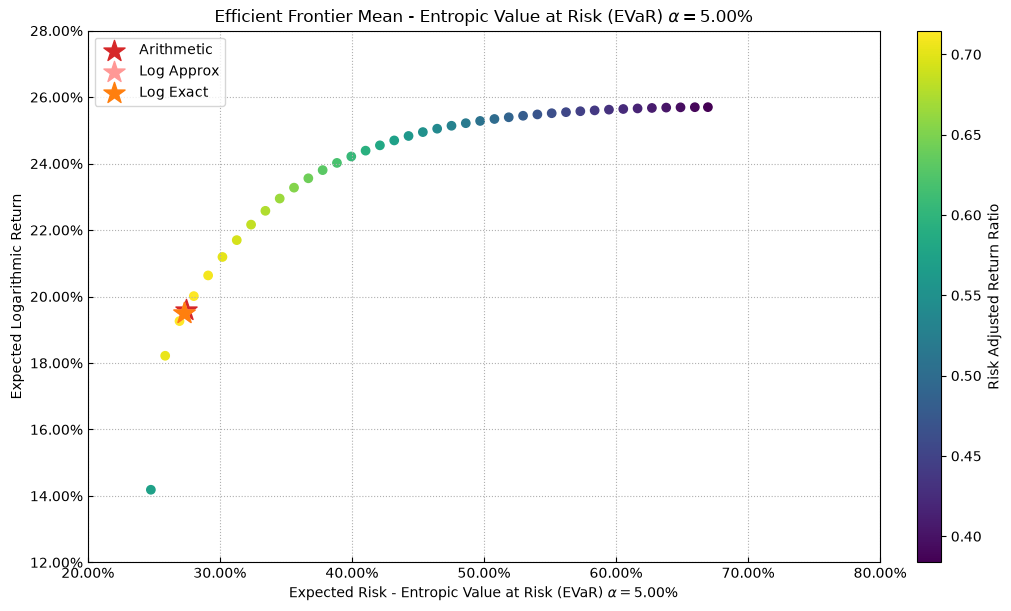

In [12]:
# Plotting the efficient frontier

label = 'Max Risk Adjusted Log Return Portfolio' # Title of point
mu = port.mu # Expected returns
cov = port.cov # Covariance matrix
returns = port.returns # Returns of the assets

fig, ax = plt.subplots(figsize=(10,6))
rp.plot_frontier(w_frontier=frontier,
                 mu=mu,
                 cov=cov,
                 returns=returns,
                 rm=rm,
                 kelly=True,
                 rf=rf,
                 alpha=0.05,
                 cmap='viridis',
                 w=w,
                 label=label,
                 marker='*',
                 s=16,
                 c='r',
                 height=6,
                 width=10,
                 t_factor=12,
                 ax=ax)

## 3. Estimating Logarithmic Mean EDaR Portfolios

### 3.1 Calculating the portfolio that maximizes Risk Adjusted Return.

In [13]:
rm = 'EDaR' # Risk measure

w_1 = port.optimization(model=model, rm=rm, obj=obj, kelly=None, rf=rf, l=l, hist=hist)
w_2 = port.optimization(model=model, rm=rm, obj=obj, kelly='approx', rf=rf, l=l, hist=hist)
w_3 = port.optimization(model=model, rm=rm, obj=obj, kelly='exact', rf=rf, l=l, hist=hist)

w = pd.concat([w_1, w_2, w_3], axis=1)
w.columns = ['Arithmetic', 'Log Approx', 'Log Exact']

display(w.style.format("{:.2%}").background_gradient(cmap='YlGn'))

,Arithmetic,Log Approx,Log Exact
AIG,0.00%,0.00%,0.00%
AKAM,0.00%,0.00%,0.00%
AMT,0.00%,0.00%,0.00%
APA,4.09%,4.08%,4.53%
BA,0.00%,0.00%,0.00%
BAX,0.00%,0.00%,0.00%
BKNG,1.52%,2.17%,1.91%
BMY,0.00%,0.00%,0.00%
CMCSA,0.00%,0.00%,0.00%
CNP,0.00%,0.00%,0.00%


<Axes: >

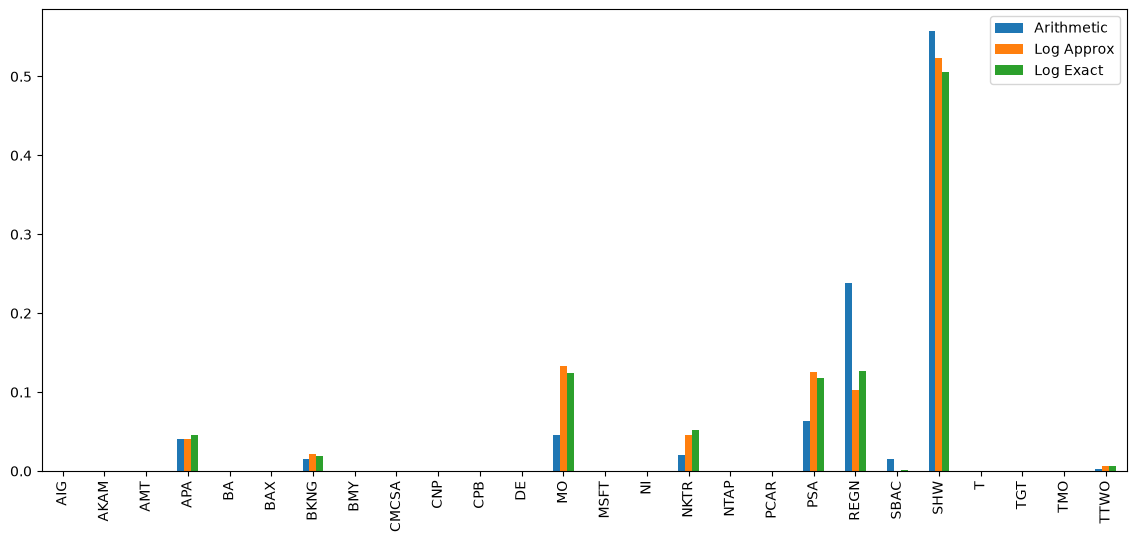

In [14]:
fig, ax = plt.subplots(figsize=(14,6))
w.plot(kind='bar', ax = ax)

In [15]:
returns = port.returns
cov = port.cov

y = 1/(returns.shape[0]) * np.sum(np.log(1 + returns @ w_1.to_numpy()))
x = rp.Sharpe_Risk(returns=returns, w=w_1, cov=cov, rm=rm, rf=rf, alpha=0.05)
print("Risk Adjusted Return:")
print("Arithmetic", (y/x).item() * 12)

y = 1/(returns.shape[0]) * np.sum(np.log(1 + returns @ w_2.to_numpy()))
x = rp.Sharpe_Risk(returns=returns, w=w_2, cov=cov, rm=rm, rf=rf, alpha=0.05)
print("Log Approx", (y/x).item() * 12)

y = 1/(returns.shape[0]) * np.sum(np.log(1 + returns @ w_3.to_numpy()))
x = rp.Sharpe_Risk(returns=returns, w=w_3, cov=cov, rm=rm, rf=rf, alpha=0.05)
print("Log Exact", (y/x).item() * 12)

Risk Adjusted Return:
Arithmetic 1.0151673031271895
Log Approx 1.0354055457526827
Log Exact 1.0368070560421656


### 3.2 Calculate efficient frontier

In [16]:
points = 40 # Number of points of the frontier

frontier = port.efficient_frontier(model=model, rm=rm, kelly="exact", points=points, rf=rf, hist=hist)

display(frontier.T.head())

,AIG,AKAM,AMT,APA,BA,BAX,BKNG,BMY,CMCSA,CNP,...,NTAP,PCAR,PSA,REGN,SBAC,SHW,T,TGT,TMO,TTWO
0,0.0000%,0.0000%,0.0000%,11.2057%,0.0000%,0.0000%,5.2098%,10.6859%,0.0000%,0.0000%,...,0.0000%,0.0000%,20.3467%,0.0000%,0.0000%,42.6290%,0.0000%,0.0000%,0.0000%,0.0000%
1,0.0000%,0.0000%,0.0000%,7.8101%,0.0000%,0.0000%,2.4550%,0.0000%,0.0000%,0.0000%,...,0.0000%,0.0000%,16.0995%,7.2341%,0.0000%,46.3375%,0.0000%,0.0000%,0.0000%,0.0000%
2,0.0000%,0.0000%,0.0000%,5.0549%,0.0000%,0.0000%,1.8504%,0.0000%,0.0000%,0.0000%,...,0.0000%,0.0000%,12.5511%,12.3642%,0.0256%,50.2998%,0.0000%,0.0000%,0.0000%,0.2620%
3,0.0000%,0.0000%,0.0000%,2.3835%,0.0000%,0.0000%,2.0440%,0.0000%,0.0000%,0.0000%,...,0.0000%,0.0000%,8.8073%,14.0599%,0.8938%,52.2752%,0.0000%,0.0000%,0.0000%,2.1747%
4,0.0000%,0.0000%,0.0000%,0.0000%,0.0000%,0.0000%,2.2910%,0.0000%,0.0000%,0.0000%,...,0.0000%,0.0000%,5.4526%,15.9260%,1.6854%,54.3154%,0.0000%,0.0000%,0.0000%,3.8441%


<Axes: >

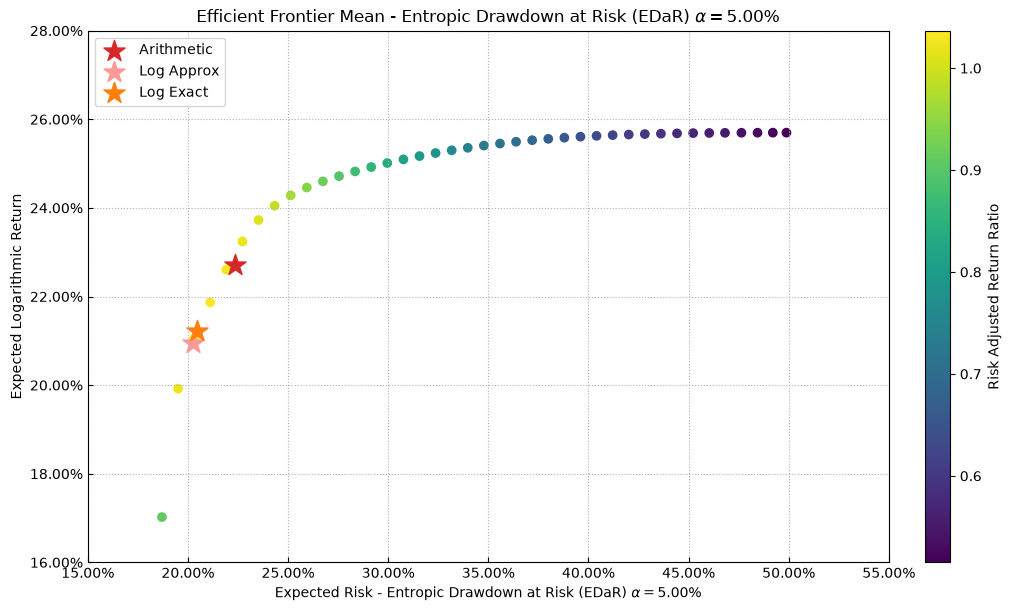

In [17]:
# Plotting the efficient frontier

label = 'Max Risk Adjusted Log Return Portfolio' # Title of point
mu = port.mu # Expected returns
cov = port.cov # Covariance matrix
returns = port.returns # Returns of the assets

fig, ax = plt.subplots(figsize=(10,6))
rp.plot_frontier(w_frontier=frontier,
                 mu=mu,
                 cov=cov,
                 returns=returns,
                 rm=rm,
                 kelly=True,
                 rf=rf,
                 alpha=0.05,
                 cmap='viridis',
                 w=w,
                 label=label,
                 marker='*',
                 s=16,
                 c='r',
                 height=6,
                 width=10,
                 t_factor=12,
                 ax=ax)